In [1]:
import numpy as np
import pandas as pd
from scipy.stats import mood
from sklearn.cluster import SpectralClustering
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt

In [4]:
y = pd.read_csv("/work/y_scaled.csv", index_col=0)
X = pd.read_csv("/work/X.csv", index_col=0)
X_test = X[1176:]
y_test = y[1176:]
X = X[0:1176]
y = y[0:1176]
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
y

,SPX
Date,
2019-06-26,-0.519832
2019-06-27,-0.592789
2019-06-28,-0.623760
2019-07-01,0.310387
2019-07-02,-0.626156
...,...
2024-02-21,-0.497922
2024-02-22,0.359495
2024-02-23,-0.486180


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
XY_combined = X.copy()
XY_combined["SPX"] = y

In [14]:
best_k

NameError: name 'best_k' is not defined

In [13]:
! pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.6/865.6 kB 42.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [17]:
import numpy as np
import pandas as pd
from sklearn.cluster import SpectralClustering

# Assume XY_combined is your multivariable DataFrame (with lagged features)

n_clusters = 4  # number of clusters you want

spectral = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',  # use nearest neighbors affinity
    n_neighbors=10,                # number of neighbors to use in affinity graph (tune this)
    assign_labels='kmeans',
    random_state=42,
    n_jobs=-1                     # use all CPUs if available
)

labels = spectral.fit_predict(XY_combined.values)

# Add cluster labels back to dataframe
XY_combined['cluster'] = labels

print(XY_combined['cluster'])


Date
2019-06-26    1
2019-06-27    1
2019-06-28    1
2019-07-01    1
2019-07-02    1
             ..
2024-02-21    2
2024-02-22    2
2024-02-23    2
2024-02-26    2
2024-02-27    2
Name: cluster, Length: 1176, dtype: int32


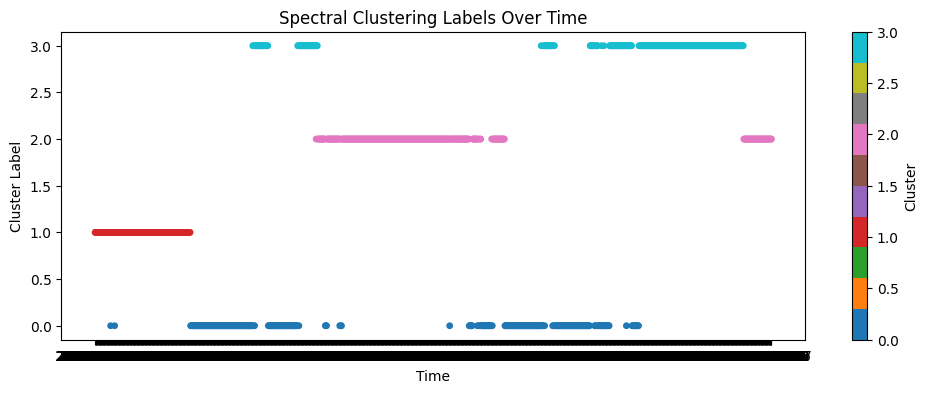

In [20]:
import matplotlib.pyplot as plt

# If your DataFrame index is time or a sequential integer index:
plt.figure(figsize=(12, 4))
plt.scatter(XY_combined.index, XY_combined['cluster'], c=XY_combined['cluster'], cmap='tab10', s=15)
plt.xlabel('Time')
plt.ylabel('Cluster Label')
plt.title('Spectral Clustering Labels Over Time')
plt.colorbar(label='Cluster')
plt.show()

In [58]:
np.unique(labels, return_counts=True)

(array([0, 1, 2, 3], dtype=int32), array([363, 164, 309, 340]))

In [79]:
!pip install hmmlearn==0.3.3


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [50]:
import numpy as np
from hmmlearn.hmm import MultinomialHMM

# Your cluster labels from spectral clustering (assumed integer labels 0..n_clusters-1)
observed_labels = XY_combined['cluster'].values.astype(int).reshape(-1, 1)

n_clusters = 4  # Number of clusters / hidden states

# Initialize HMM with n_components = n_clusters
# Here, hidden states represent smoothed latent states
hmm_model = MultinomialHMM(n_components=n_clusters, random_state=42, n_iter=500, verbose=True)

# Fit HMM to observed cluster labels (emissions)
# observed_labels shape = (n_samples, 1) as required by hmmlearn
hmm_model.fit(observed_labels)

# Decode the most likely hidden state sequence (smoothed clusters)
smoothed_states = hmm_model.predict(observed_labels)

# Add smoothed cluster labels back to your DataFrame
XY_combined['smoothed_cluster'] = smoothed_states



MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
         1       0.00000000             +nan
         2      -0.00000000      -0.00000000


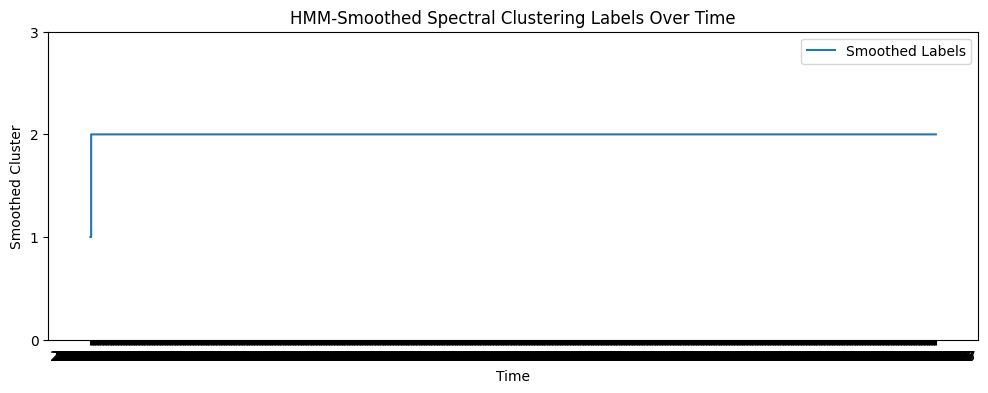

In [53]:
plt.figure(figsize=(12, 4))
plt.plot(XY_combined.index, XY_combined['smoothed_cluster'], drawstyle='steps-post', label='Smoothed Labels')
plt.xlabel('Time')
plt.ylabel('Smoothed Cluster')
plt.title('HMM-Smoothed Spectral Clustering Labels Over Time')
plt.yticks(range(n_clusters))
plt.legend()
plt.show()


In [47]:
observed_labels

array([[1],
       [1],
       [1],
       ...,
       [2],
       [2],
       [2]])

In [82]:
def elbow_analysis(y, alpha=0.05, window_range=None):
    if window_range is None:
        window_range = list(range(2, 60, 1))  # Even numbers from 2 to 28
    
    change_counts = []

    for w in window_range:
        cps = mood_segmentation(y, window=w, alpha=alpha)
        change_counts.append(len(cps))
        print(f"Window {w}: {len(cps)} change points")

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(window_range, change_counts, marker='o')
    plt.title("Elbow Method: Window Size vs. Number of Change Points")
    plt.xlabel("Window Size")
    plt.ylabel("Number of Change Points")
    plt.grid(True)
    plt.show()

    return window_range, change_counts

Window 2: 0 change points
Window 3: 0 change points
Window 4: 22 change points
Window 5: 59 change points
Window 6: 43 change points
Window 7: 43 change points
Window 8: 52 change points
Window 9: 57 change points
Window 10: 57 change points
Window 11: 50 change points
Window 12: 63 change points
Window 13: 78 change points
Window 14: 78 change points
Window 15: 86 change points
Window 16: 91 change points
Window 17: 86 change points
Window 18: 95 change points
Window 19: 101 change points
Window 20: 108 change points
Window 21: 108 change points
Window 22: 113 change points
Window 23: 124 change points
Window 24: 133 change points
Window 25: 145 change points
Window 26: 142 change points
Window 27: 158 change points
Window 28: 165 change points
Window 29: 164 change points
Window 30: 170 change points
Window 31: 172 change points
Window 32: 177 change points
Window 33: 178 change points
Window 34: 195 change points
Window 35: 193 change points
Window 36: 179 change points
Window 37: 1

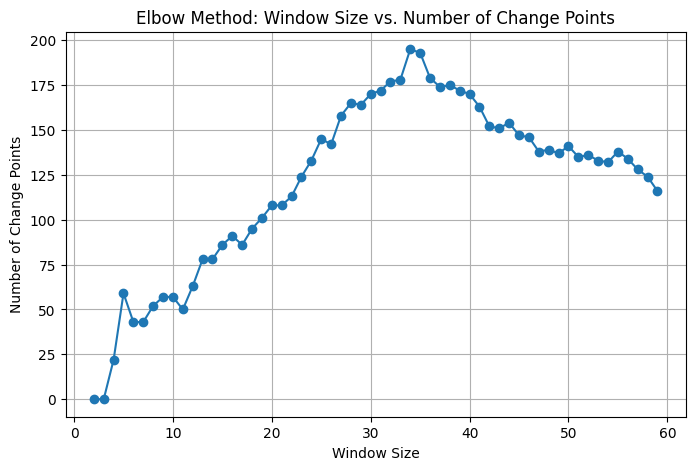

In [97]:
window_range, change_counts = elbow_analysis(y)

In [102]:
def find_max_curvature_point(x, y, edge_ignore=2):
    x = np.array(x, dtype=np.float64)
    y = np.array(y, dtype=np.float64)

    dx = np.gradient(x)
    dy = np.gradient(y)

    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
    curvature = np.nan_to_num(curvature)

    # Ignore edges
    valid_range = slice(edge_ignore, -edge_ignore)

    max_idx_inside = np.argmax(curvature[valid_range])
    max_idx = max_idx_inside + edge_ignore

    return max_idx, curvature

In [108]:
find_max_curvature_point(window_range, change_counts)

(14,
 array([1.10000000e+01, 1.09459201e-02, 9.72133305e-06, 1.59790606e-02,
        5.72468006e-03, 7.65636910e-02, 2.82842712e-03, 2.68938076e-01,
        5.18341751e-03, 2.76699295e-01, 8.13735343e-04, 1.15426830e-02,
        7.13340074e-03, 7.03154609e-03, 2.25000000e+00, 3.35410197e-01,
        5.19420734e-03, 7.03154609e-03, 4.14673401e-02, 1.15259175e-01,
        7.15585007e-03, 1.23148167e-03, 2.34359555e-03, 2.04169843e-02,
        1.23052057e-02, 1.13772479e-03, 1.42302495e-01, 2.56131501e-02,
        7.13340074e-03, 1.03668350e-02, 8.69626357e-02, 3.03013334e-03,
        1.96225611e-02, 1.62199268e-02, 3.44169155e-03, 3.80131556e-01,
        8.83883476e-02, 8.96460253e-02, 3.31775994e-02, 1.01004445e-03,
        2.22160794e-02, 7.07106781e-01, 2.23606798e-01, 1.78335018e-02,
        2.55212303e-03, 4.14673401e-02, 1.60996894e+00, 8.83883476e-02,
        6.18718434e-01, 0.00000000e+00, 8.83883476e-02, 1.56524758e-01,
        7.68394503e-02, 1.32582521e+00, 2.26287848e-02, 3.7